地形文件信息说明
- 'terrain_3d': 三维可通行性布尔数组，shape=(ny_samples, nx_samples, nz_samples)
  * True: 该位置为山体（不可通行）
  * False: 该位置为水/空隙（可通行）
- 'bathymetry_2d': 二维海深数组，shape=(ny_samples, nx_samples) [m]
  * 每个网格点的海底深度值（从插值获得）
- 'x_coords': 水平面x坐标数组 [km]
- 'y_coords': 水平面y坐标数组 [km]
- 'z_coords': 高度坐标数组 [m]
- 'x_range': 原始x范围 [km]
- 'y_range': 原始y范围 [km]
- 'max_depth': 最大深度 [m]
- 'resample_params': 重采样参数字典

['terrain_3d', 'bathymetry_2d', 'x_coords', 'y_coords', 'z_coords', 'x_range', 'y_range', 'max_depth', 'resample_params']
key              : shape
terrain_3d       : (101, 101, 11)
bathymetry_2d    : (101, 101)
x_coords         : (101,)
y_coords         : (101,)
z_coords         : (11,)
x_range          : (2,)
y_range          : (2,)
max_depth        : ()
resample_params  : ()
x_range          : [ 0. 10.]
y_range          : [ 0. 10.]
max_depth        : 550.0
resample_params  : {'x_step': 0.1, 'y_step': 0.1, 'z_step': 0.05}


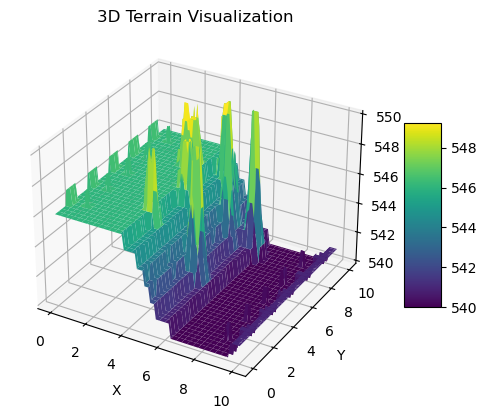

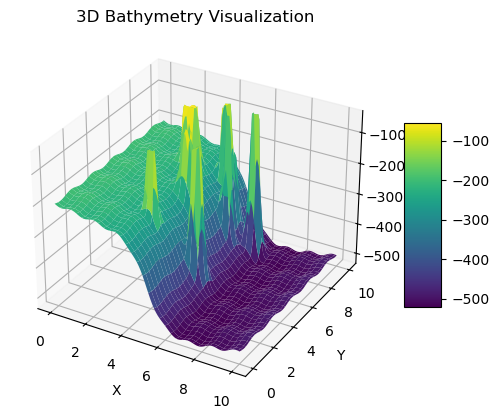

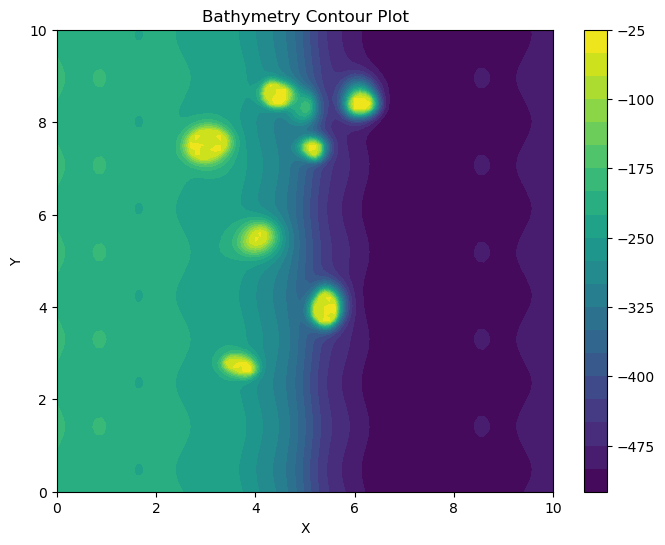

In [5]:
import numpy as np

kp = np.load("output/bty/terrain.npz", allow_pickle=True)
print(kp.files)
print("{:<16s} : {}".format("key", "shape"))
for key in kp.files:
    print("{:<16s} : {}".format(key, kp[key].shape))
print("{:<16s} : {}".format("x_range", str(kp["x_range"])))
print("{:<16s} : {}".format("y_range", str(kp["y_range"])))
print("{:<16s} : {}".format("max_depth", str(kp["max_depth"])))
print("{:<16s} : {}".format("resample_params", str(kp["resample_params"])))

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# 画出地形数据
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# 获取坐标范围
x_range = kp["x_range"]  # (0.0, 100.0)
y_range = kp["y_range"]  # (0.0, 100.0)
max_depth = kp["max_depth"]  # 10.0
# 创建坐标网格
x = np.linspace(x_range[0], x_range[1], kp["terrain_3d"].shape[0])
y = np.linspace(y_range[0], y_range[1], kp["terrain_3d"].shape[1])
X, Y = np.meshgrid(x, y)
# 获取地形高度数据
Z = np.zeros_like(X)
for i in range(kp["terrain_3d"].shape[0]):
    for j in range(kp["terrain_3d"].shape[1]):
        # 从上到下找到第一个 True（山体）的位置，计算高度
        terrain_column = kp["terrain_3d"][i, j, :]
        if np.any(terrain_column):
            first_solid_idx = np.argmax(terrain_column)  # 第一个 True 的索引
            Z[i, j] = max_depth - first_solid_idx  # 高度 = 最大深度 - 索引位置
        else:
            Z[i, j] = 0.0  # 如果全是 False（水/空隙），高度为0
# 绘制地形表面
surf = ax.plot_surface(X, Y, Z, cmap="viridis")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Height')
ax.set_title('3D Terrain Visualization')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

# 根据高度表 bathymetry_2d 绘制三维地形
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# 获取坐标范围
x_range = kp["x_range"]  # (0.0, 100.0)
y_range = kp["y_range"]  # (0.0, 100.0)
# 创建坐标网格
x = np.linspace(x_range[0], x_range[1], kp["bathymetry_2d"].shape[0])
y = np.linspace(y_range[0], y_range[1], kp["bathymetry_2d"].shape[1])
X, Y = np.meshgrid(x, y)
# 获取海深数据
Z = -kp["bathymetry_2d"]  # 海深为负值
# 绘制地形表面
surf = ax.plot_surface(X, Y, Z, cmap="viridis")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Depth')
ax.set_title('3D Bathymetry Visualization')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

# 根据 bathymetry_2d 绘制等高线图
plt.figure(figsize=(8, 6))
x_range = kp["x_range"]  # (0.0, 100.0)
y_range = kp["y_range"]  # (0.0, 100.0)
x = np.linspace(x_range[0], x_range[1], kp["bathymetry_2d"].shape[0])
y = np.linspace(y_range[0], y_range[1], kp["bathymetry_2d"].shape[1])
X, Y = np.meshgrid(x, y)
Z = -kp["bathymetry_2d"]  # 海深为负值
contour = plt.contourf(X, Y, Z, levels=20, cmap="viridis")
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Bathymetry Contour Plot')
plt.colorbar(contour)
plt.show()

下面是声学计算点对文件的内容列表

In [7]:
import numpy as np

kp = np.load("output/keypoints/key_points.npz", allow_pickle=True)
print(kp.files)
print(kp["key_pairs"].shape)
print(kp["key_pair_columns"].shape)
print(kp["enemy_x"].shape, end=" enemy_x=")
print(kp["enemy_x"])
print(kp["enemy_z"].shape, end=' enemy_z=')
print(kp["enemy_z"])

['key_pairs', 'key_pair_columns', 'enemy_x', 'enemy_z']
(2394360, 4)
(4,)
() enemy_x=2000
() enemy_z=150
